In [ ]:
%pip install yellowbrick

In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import tree
from yellowbrick.cluster import SilhouetteVisualizer



In [4]:
df=pd.read_csv('processed_data (3).csv')
df.shape
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,Senior,0,1,Yes,Private,Rural,Normal,Obese,never smoked,1
1,Male,Senior,1,1,Yes,Private,Rural,Low,Overweight,never smoked,1
2,Female,Senior,0,0,No,Private,Urban,Low,Normal,never smoked,1
3,Female,Senior,0,0,Yes,Private,Rural,Low,Overweight,Unknown,1
4,Female,Senior,0,0,Yes,Private,Urban,Low,Normal,Unknown,1


##Encoding

In [5]:
encoder = LabelEncoder()
df['age'] = encoder.fit_transform(df['age'])
df['avg_glucose_level'] = encoder.fit_transform(df['avg_glucose_level'])
df['bmi'] = encoder.fit_transform(df['bmi'])
df['gender'] = encoder.fit_transform(df['gender'])

df['work_type'] = encoder.fit_transform(df['work_type'])
df['Residence_type'] = encoder.fit_transform(df['Residence_type'])
df['smoking_status'] = encoder.fit_transform(df['smoking_status'])
df['ever_married'] = encoder.fit_transform(df['ever_married'])

print("✓ Categorical columns encoded successfully!")
print("\nEncoded Data Sample:")
print(df[['gender','age','avg_glucose_level','bmi', 'work_type', 'Residence_type', 'smoking_status', 'ever_married']].head())

✓ Categorical columns encoded successfully!

Encoded Data Sample:
   gender  age  avg_glucose_level  bmi  work_type  Residence_type  \
0       1    1                  2    1          2               0   
1       1    1                  1    2          2               0   
2       0    1                  1    0          2               1   
3       0    1                  1    2          2               0   
4       0    1                  1    0          2               1   

   smoking_status  ever_married  
0               2             1  
1               2             1  
2               2             0  
3               0             1  
4               0             1  


## Feature Preparation

In [6]:
fn = df.keys().tolist()[:-1]
X = df[fn]
y = df.iloc[:, -1]


categorical_cols = X.select_dtypes(include=['object']).columns


X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
df.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,1,1,0,1,1,2,0,2,1,2,1
1,1,1,1,1,1,2,0,1,2,2,1
2,0,1,0,0,0,2,1,1,0,2,1
3,0,1,0,0,1,2,0,1,2,0,1
4,0,1,0,0,1,2,1,1,0,0,1


#**GINI**

### 90% training / 10% testing

#### Splitting Data


In [39]:
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print(f"Training set size: {len(X_train_90)} samples")
print(f"Testing set size: {len(X_test_10)} samples\n")

Training set size: 3951 samples
Testing set size: 440 samples



#### Building Decision Tree Model

In [40]:
clf_gini_90_10 = DecisionTreeClassifier(criterion='gini',max_depth=5, random_state=42)
clf_gini_90_10 = clf_gini_90_10.fit(X_train_90, y_train_90)

####  Predict


In [41]:
y_pred_90_10 = clf_gini_90_10.predict(X_test_10)


#### Evaluate

In [42]:
accuracy_90_10 = metrics.accuracy_score(y_test_10, y_pred_90_10)
print(f"Accuracy: {accuracy_90_10:.4f}")
print(f"Accuracy: {accuracy_90_10*100:.2f}%\n")

Accuracy: 0.9523
Accuracy: 95.23%



#### Confusion Matrix

In [43]:
cm_90_10 = confusion_matrix(y_test_10, y_pred_90_10)
print("Confusion Matrix:")
print(cm_90_10)
print()

Confusion Matrix:
[[419   0]
 [ 21   0]]



#### Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

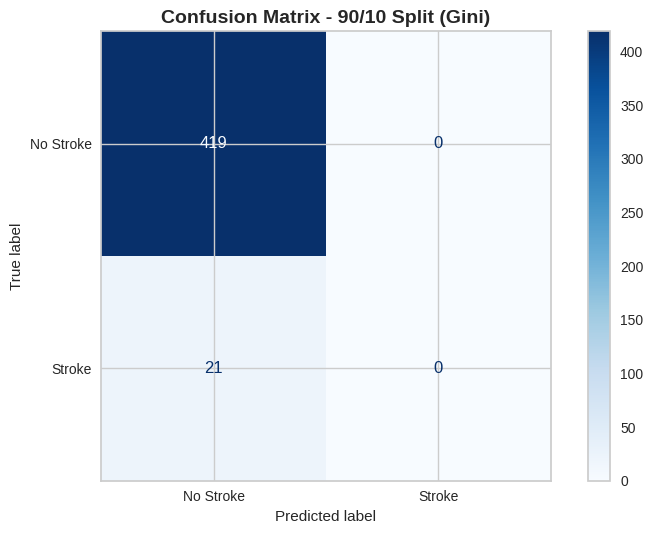

In [44]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_90_10, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - 90/10 Split (Gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

####  Visualize Decision Tree

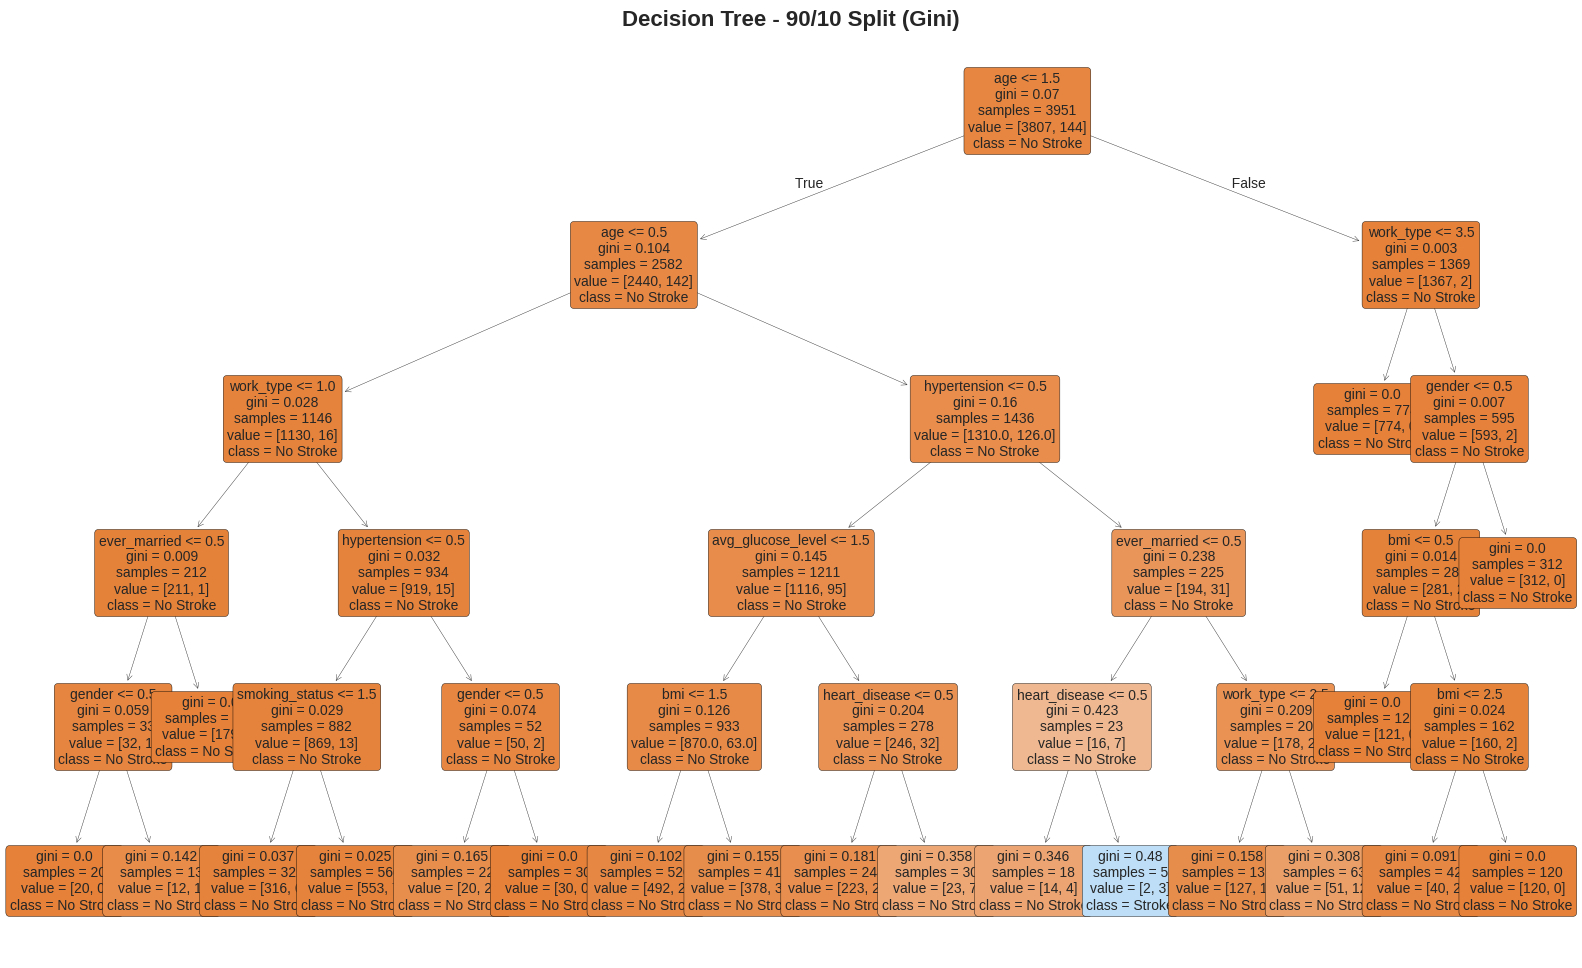

In [45]:
plt.figure(figsize=(20, 12))
tree.plot_tree(clf_gini_90_10,
               feature_names=fn,
               class_names=['No Stroke', 'Stroke'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree - 90/10 Split (Gini)', fontsize=16, fontweight='bold')
plt.savefig('dt_90_10_gini.png', dpi=300, bbox_inches='tight')
plt.show()

## 80% training / 20% testing

#### Splitting Data


In [46]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train_80)} samples")
print(f"Testing set size: {len(X_test_20)} samples\n")


Training set size: 3512 samples
Testing set size: 879 samples



#### Building Decision Tree Model

In [47]:
clf_gini_80_20 = DecisionTreeClassifier(criterion='gini',max_depth=5, random_state=42)
clf_gini_80_20.fit(X_train_80, y_train_80)

DecisionTreeClassifier(max_depth=5, random_state=42)

####  Predict


In [48]:
y_pred_80_20 = clf_gini_80_20.predict(X_test_20)


#### Evaluate

In [49]:
accuracy_80_20 = metrics.accuracy_score(y_test_20, y_pred_80_20)
print(f"Accuracy: {accuracy_80_20:.4f}")
print(f"Accuracy: {accuracy_80_20*100:.2f}%\n")

Accuracy: 0.9579
Accuracy: 95.79%



#### Confusion Matrix

In [50]:
cm_80_20 = confusion_matrix(y_test_20, y_pred_80_20)
print("Confusion Matrix:")
print(cm_80_20)
print()

Confusion Matrix:
[[842   1]
 [ 36   0]]



#### Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

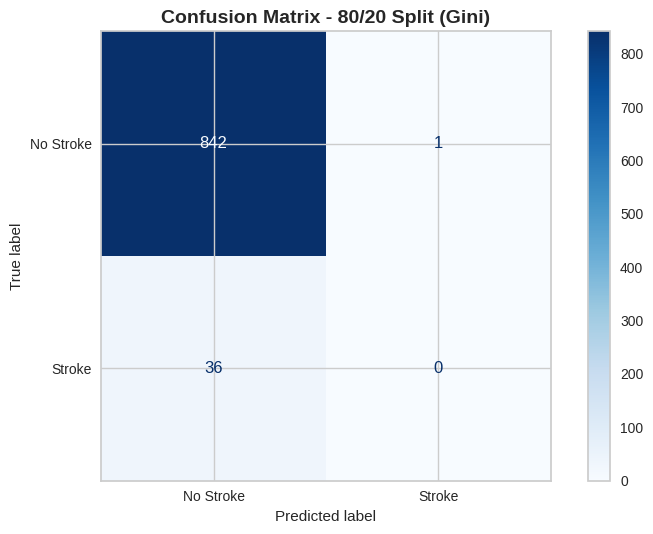

In [51]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_80_20, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - 80/20 Split (Gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


####  Visualize Decision Tree

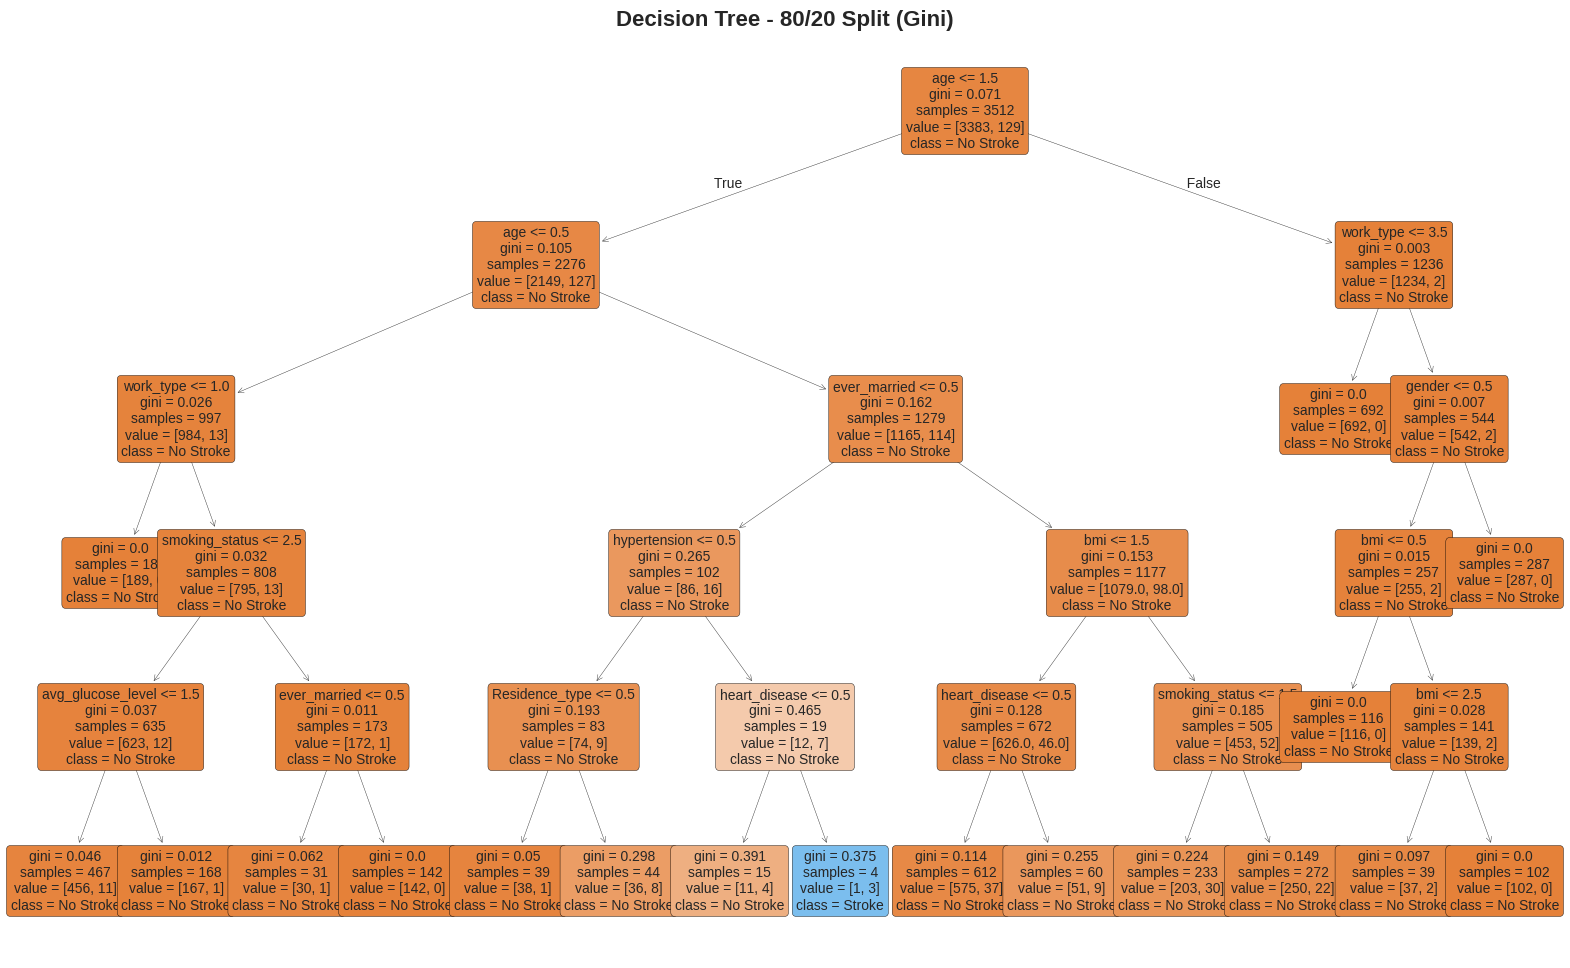

In [52]:
plt.figure(figsize=(20, 12))
tree.plot_tree(clf_gini_80_20,
               feature_names=fn,
               class_names=['No Stroke', 'Stroke'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree - 80/20 Split (Gini)', fontsize=16, fontweight='bold')
plt.savefig('dt_80_20_gini.png', dpi=300, bbox_inches='tight')
plt.show()

## 70% training / 30% testing

#### Splitting Data


In [53]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training set size: {len(X_train_70)} samples")
print(f"Testing set size: {len(X_test_30)} samples\n")


Training set size: 3073 samples
Testing set size: 1318 samples



#### Building Decision Tree Model

In [54]:
clf_gini_70_30 = DecisionTreeClassifier(criterion='gini',max_depth=5, random_state=42)
clf_gini_70_30.fit(X_train_70, y_train_70)


DecisionTreeClassifier(max_depth=5, random_state=42)

####  Predict


In [55]:
y_pred_70_30 = clf_gini_70_30.predict(X_test_30)



#### Evaluate

In [56]:
accuracy_70_30 = metrics.accuracy_score(y_test_30, y_pred_70_30)
print(f"Accuracy: {accuracy_70_30:.4f}")
print(f"Accuracy: {accuracy_70_30*100:.2f}%\n")

Accuracy: 0.9605
Accuracy: 96.05%



#### Confusion Matrix

In [57]:
cm_70_30 = confusion_matrix(y_test_30, y_pred_70_30)
print("Confusion Matrix:")
print(cm_70_30)
print()

Confusion Matrix:
[[1266    0]
 [  52    0]]



#### Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

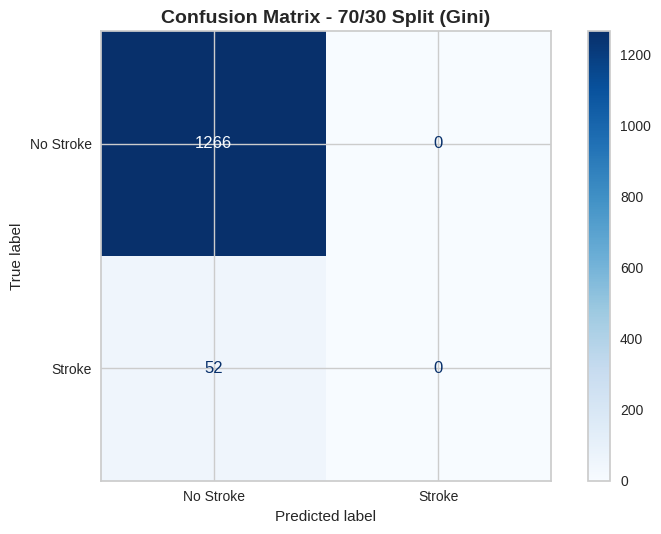

In [58]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_70_30, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - 70/30 Split (Gini)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

####  Visualize Decision Tree

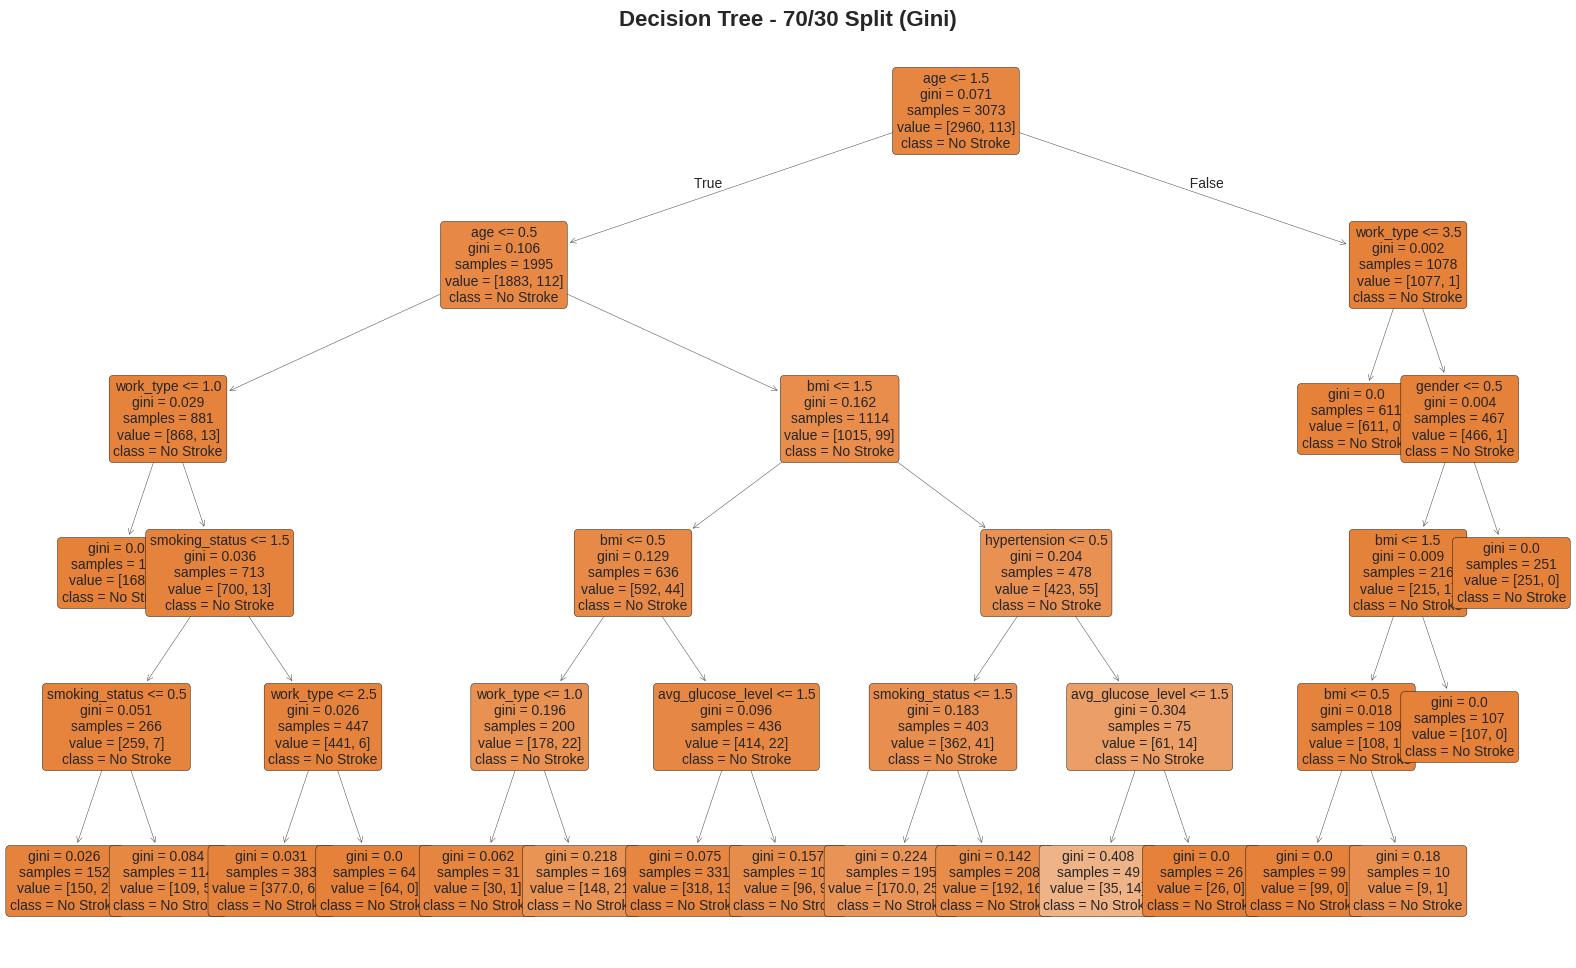

In [59]:
plt.figure(figsize=(20, 12))
tree.plot_tree(clf_gini_70_30,
               feature_names=fn,
               class_names=['No Stroke', 'Stroke'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree - 70/30 Split (Gini)', fontsize=16, fontweight='bold')
plt.savefig('dt_70_30_gini.png', dpi=300, bbox_inches='tight')
plt.show()

##COMPARISON TABLE





In [60]:
print("\n" + "="*60)
print("COMPARISON TABLE - GINI INDEX")
print("="*60 + "\n")

results_df = pd.DataFrame({
    'Split': ['90-10', '80-20', '70-30'],
    'Accuracy': [
        f"{accuracy_90_10:.4f}",
        f"{accuracy_80_20:.4f}",
        f"{accuracy_70_30:.4f}"
    ],
    'Accuracy %': [
        f"{accuracy_90_10*100:.2f}%",
        f"{accuracy_80_20*100:.2f}%",
        f"{accuracy_70_30*100:.2f}%"
    ]
})

print(results_df.to_string(index=False))


COMPARISON TABLE - GINI INDEX

Split Accuracy Accuracy %
90-10   0.9523     95.23%
80-20   0.9579     95.79%
70-30   0.9605     96.05%


###Visualization

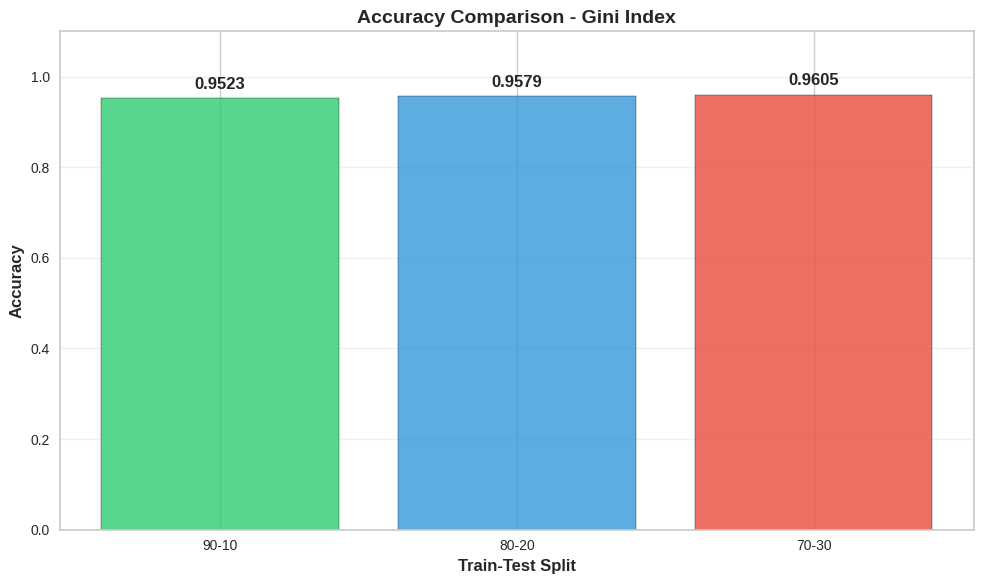

In [61]:
plt.figure(figsize=(10, 6))
splits = ['90-10', '80-20', '70-30']
accuracies = [accuracy_90_10, accuracy_80_20, accuracy_70_30]

plt.bar(splits, accuracies, color=['#2ecc71', '#3498db', '#e74c3c'], alpha=0.8, edgecolor='black')
plt.xlabel('Train-Test Split', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Accuracy Comparison - Gini Index', fontsize=14, fontweight='bold')
plt.ylim([0, 1.1])

for i, acc in enumerate(accuracies):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison_gini.png', dpi=300, bbox_inches='tight')
plt.show()


#**Entropy**

##90% training / 10% testing

#### Splitting Data

In [62]:
X_train_90, X_test_10, y_train_90, y_test_10 = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print(f"Training set size: {len(X_train_90)} samples")
print(f"Testing set size: {len(X_test_10)} samples\n")

Training set size: 3951 samples
Testing set size: 440 samples



#### Building Decision Tree Model

In [63]:
clf_entropy_90_10 = DecisionTreeClassifier(criterion='entropy',max_depth=5, random_state=42)
clf_entropy_90_10 = clf_entropy_90_10.fit(X_train_90, y_train_90)

####  Predict


In [64]:
y_pred_90_10 = clf_entropy_90_10.predict(X_test_10)


#### Evaluate

In [65]:
accuracy_90_10 = metrics.accuracy_score(y_test_10, y_pred_90_10)
print(f"Accuracy: {accuracy_90_10:.4f}")
print(f"Accuracy: {accuracy_90_10*100:.2f}%\n")

Accuracy: 0.9523
Accuracy: 95.23%



#### Confusion Matrix

In [66]:
cm_entropy_90_10 = confusion_matrix(y_test_10, y_pred_90_10)
print("Confusion Matrix:")
print(cm_entropy_90_10)
print()

Confusion Matrix:
[[419   0]
 [ 21   0]]



#### Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

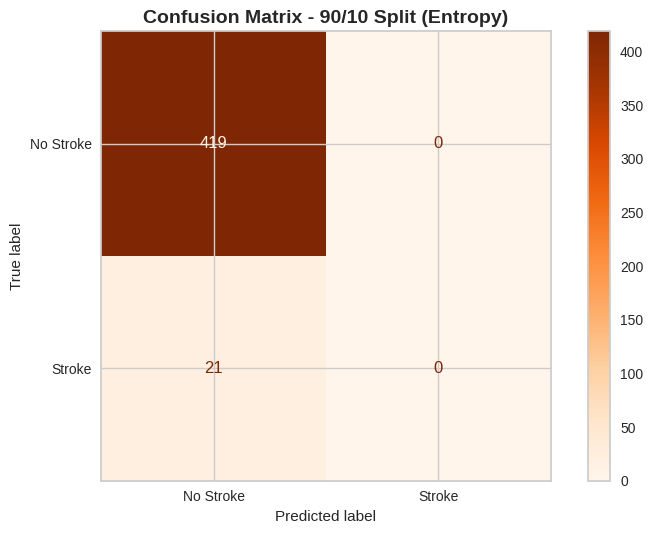

In [67]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_entropy_90_10, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix - 90/10 Split (Entropy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Visualize Decision Tree

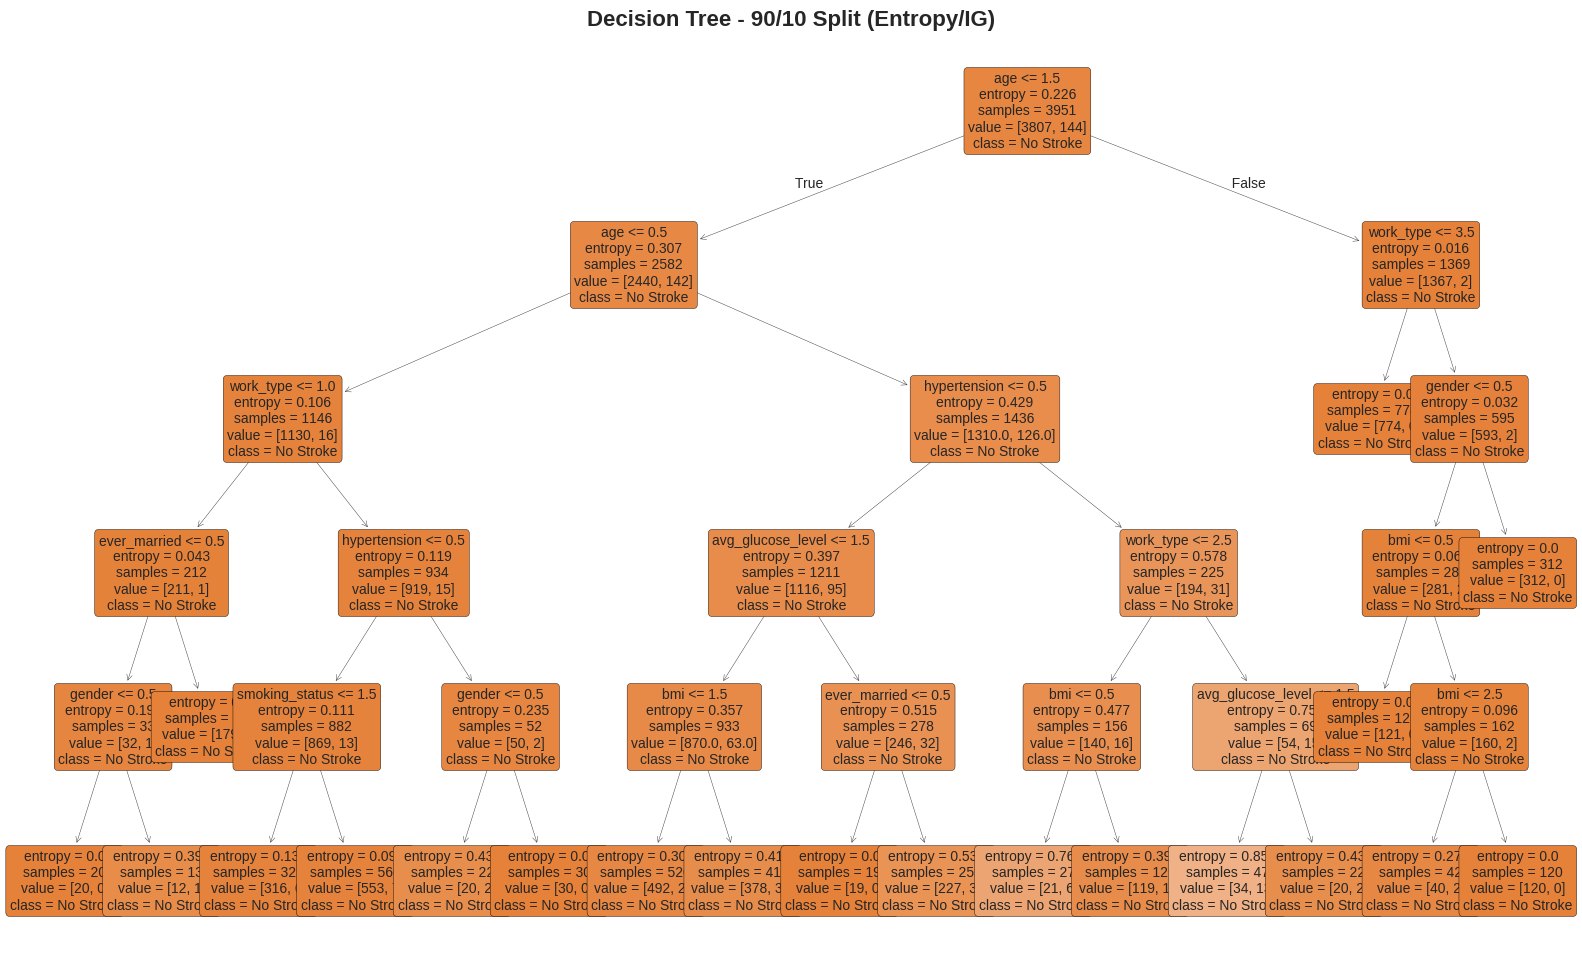

✓ Split 1 (90-10) with Entropy completed!



In [68]:
plt.figure(figsize=(20, 12))
tree.plot_tree(clf_entropy_90_10,
               feature_names=fn,
               class_names=['No Stroke', 'Stroke'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree - 90/10 Split (Entropy/IG)', fontsize=16, fontweight='bold')
plt.savefig('dt_90_10_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Split 1 (90-10) with Entropy completed!\n")

##80% training / 20% testing

#### Splitting Data

In [69]:
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print(f"Training set size: {len(X_train_80)} samples")
print(f"Testing set size: {len(X_test_20)} samples\n")

Training set size: 3951 samples
Testing set size: 440 samples



#### Building Decision Tree Model

In [70]:
clf_entropy_80_20 = DecisionTreeClassifier(criterion='entropy',max_depth=5, random_state=42)
clf_entropy_80_20 = clf_entropy_80_20.fit(X_train_80, y_train_80)

####  Predict


In [71]:
y_pred_80_20 = clf_entropy_80_20.predict(X_test_20)


#### Evaluate

In [72]:
accuracy_80_20 = metrics.accuracy_score(y_test_20, y_pred_80_20)
print(f"Accuracy: {accuracy_80_20:.4f}")
print(f"Accuracy: {accuracy_80_20*100:.2f}%\n")

Accuracy: 0.9523
Accuracy: 95.23%



#### Confusion Matrix

In [73]:
cm_entropy_80_20 = confusion_matrix(y_test_20, y_pred_80_20)
print("Confusion Matrix:")
print(cm_entropy_80_20)
print()


Confusion Matrix:
[[419   0]
 [ 21   0]]



#### Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

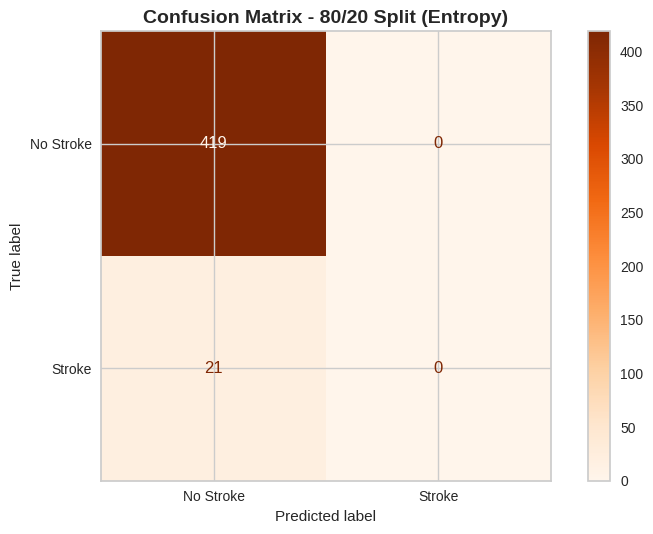

In [74]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_entropy_80_20, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix - 80/20 Split (Entropy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

####Visualize Decision Tree

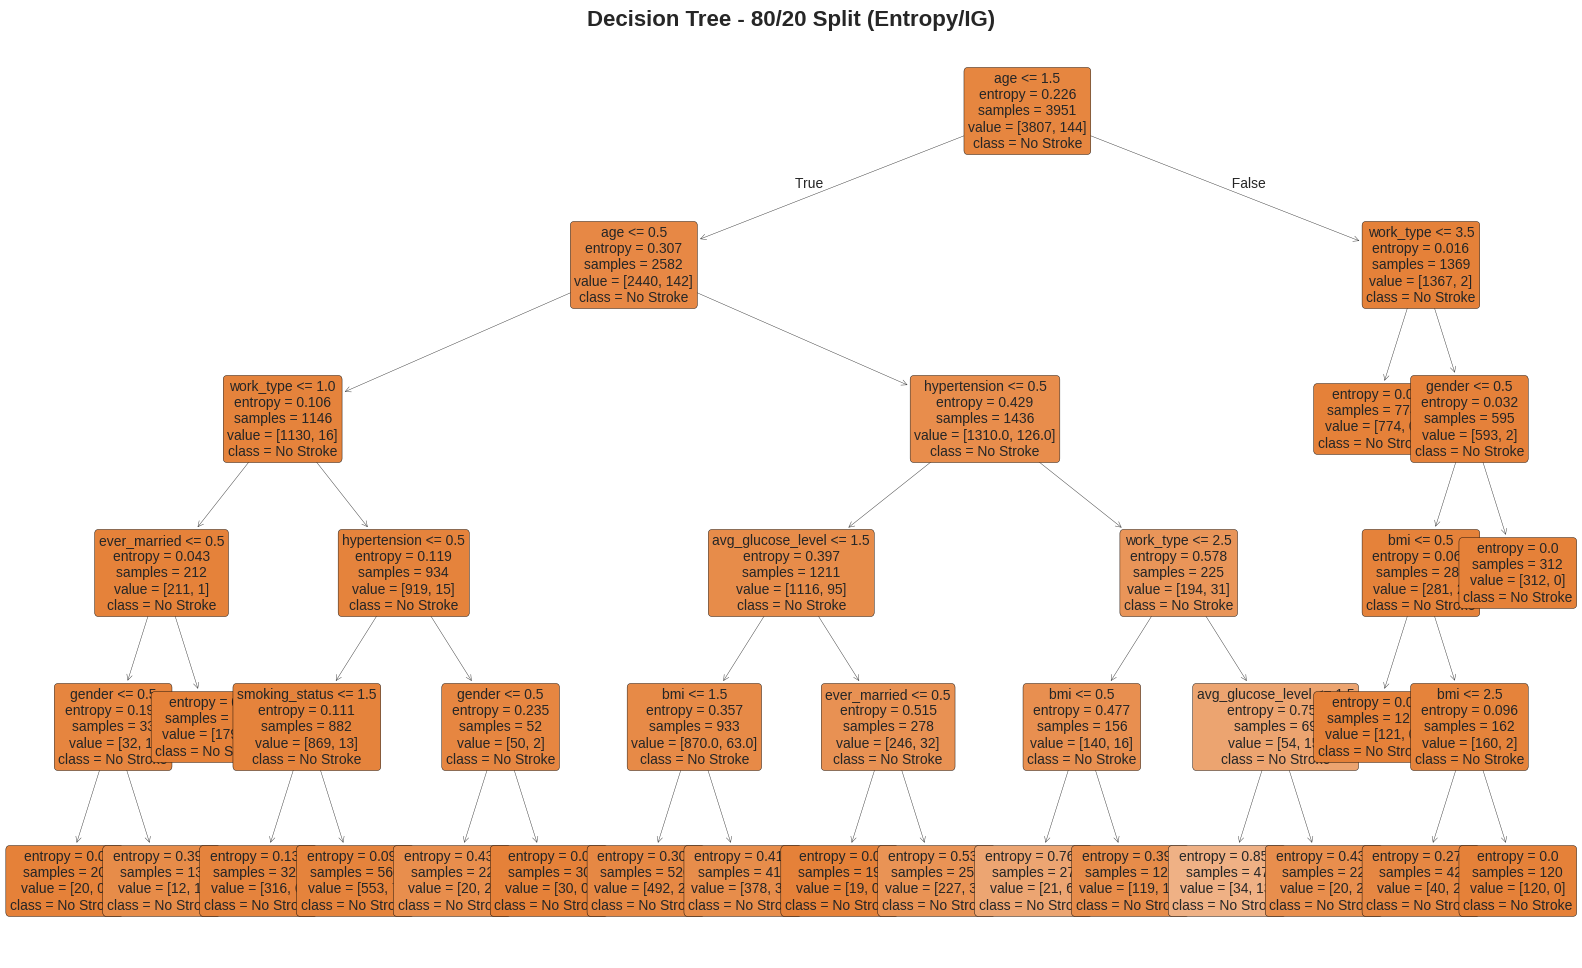

✓ Split 2 (80-20) with Entropy completed!



In [75]:
plt.figure(figsize=(20, 12))
tree.plot_tree(clf_entropy_80_20,
               feature_names=fn,
               class_names=['No Stroke', 'Stroke'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree - 80/20 Split (Entropy/IG)', fontsize=16, fontweight='bold')
plt.savefig('dt_80_20_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Split 2 (80-20) with Entropy completed!\n")

##70% training / 30% testing

#### Splitting Data

In [76]:
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42,
)
print(f"Training set size: {len(X_train_70)} samples")
print(f"Testing set size: {len(X_test_30)} samples\n")

Training set size: 3073 samples
Testing set size: 1318 samples



#### Building Decision Tree Model

In [77]:
clf_entropy_70_30 = DecisionTreeClassifier(criterion='entropy',max_depth=5, random_state=42)
clf_entropy_70_30.fit(X_train_70, y_train_70)


DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

####Predict

In [78]:
y_pred_70_30 = clf_entropy_70_30.predict(X_test_30)

#### Evaluate

In [79]:
accuracy_entropy_70_30 = metrics.accuracy_score(y_test_30, y_pred_70_30)
print(f"Accuracy: {accuracy_entropy_70_30:.4f}")
print(f"Accuracy: {accuracy_entropy_70_30*100:.2f}%\n")

Accuracy: 0.9605
Accuracy: 96.05%



#### Confusion Matrix

In [80]:
cm_entropy_70_30 = confusion_matrix(y_test_30, y_pred_70_30)
print("Confusion Matrix:")
print(cm_entropy_70_30)
print()


Confusion Matrix:
[[1266    0]
 [  52    0]]



#### Visualize Confusion Matrix

<Figure size 800x600 with 0 Axes>

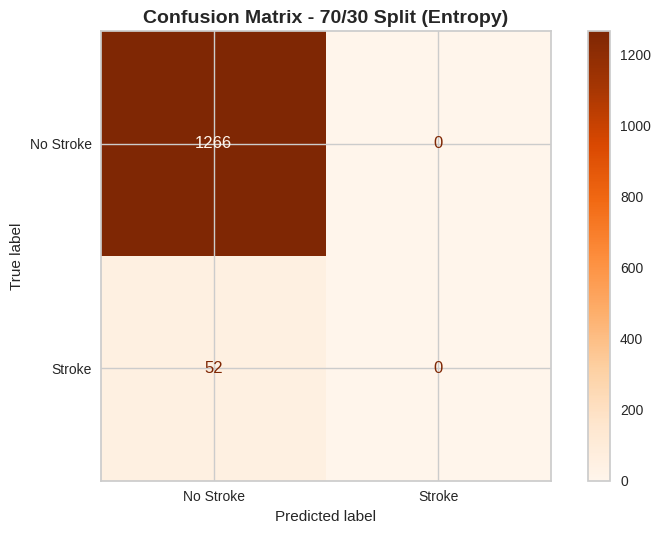

In [81]:
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_entropy_70_30, display_labels=['No Stroke', 'Stroke'])
disp.plot(cmap='Oranges', values_format='d')
plt.title('Confusion Matrix - 70/30 Split (Entropy)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#### Visualize Decision Tree

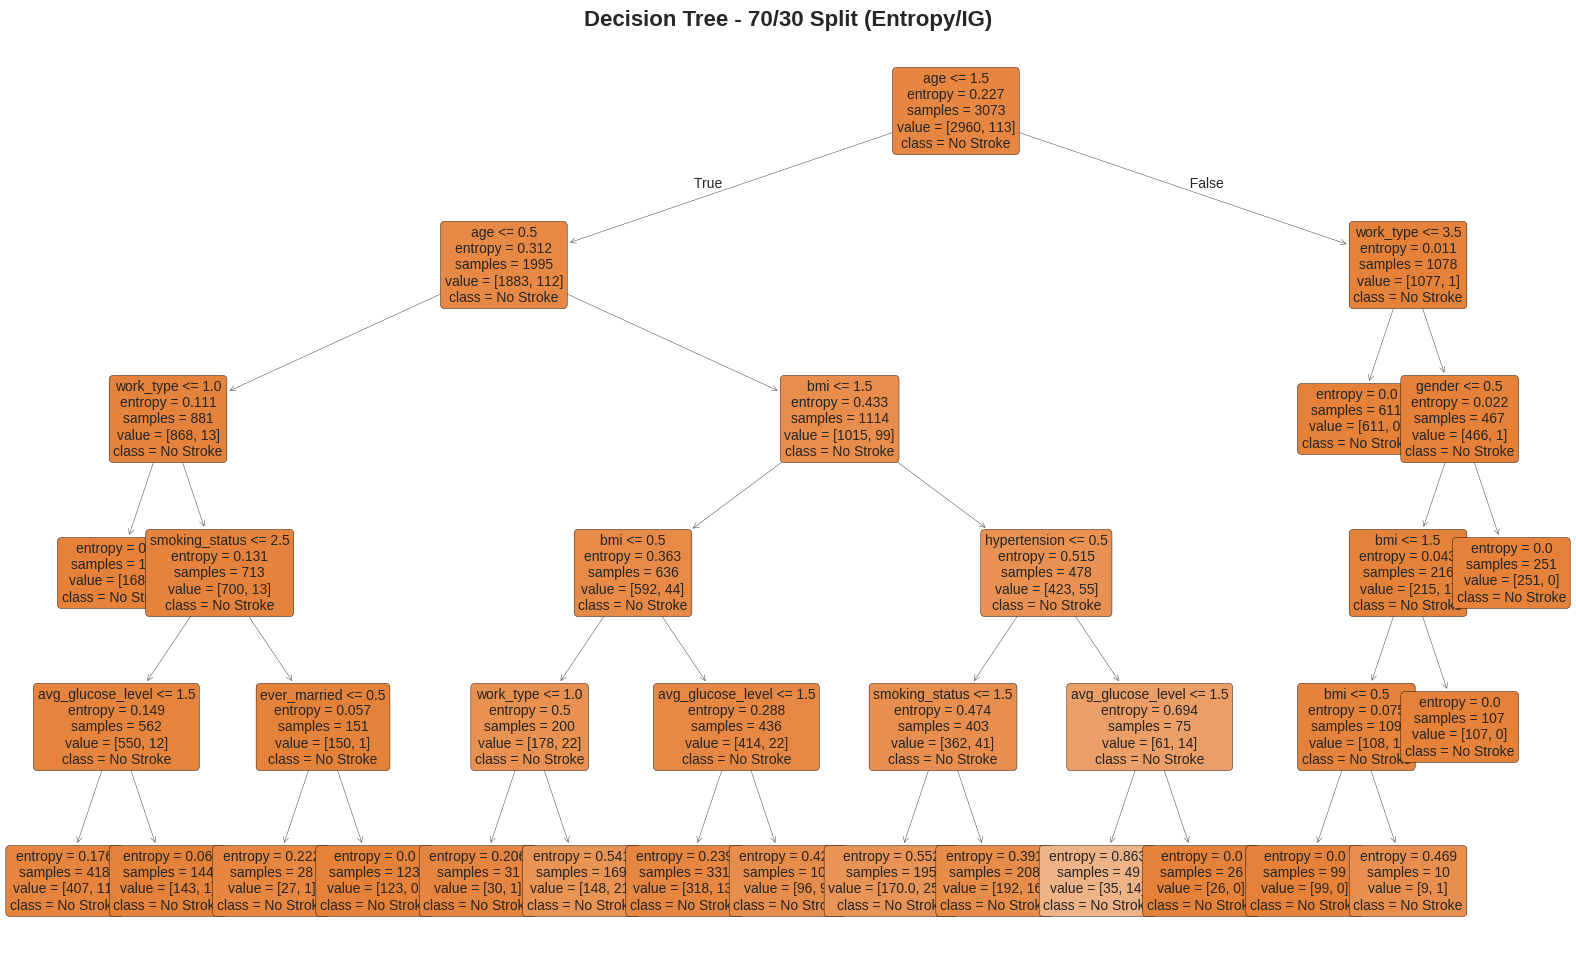

✓ Split 3 (70-30) with Entropy completed!



In [82]:
plt.figure(figsize=(20, 12))
tree.plot_tree(clf_entropy_70_30,
               feature_names=fn,
               class_names=['No Stroke', 'Stroke'],
               filled=True,
               rounded=True,
               fontsize=10)
plt.title('Decision Tree - 70/30 Split (Entropy/IG)', fontsize=16, fontweight='bold')
plt.savefig('dt_70_30_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Split 3 (70-30) with Entropy completed!\n")

## COMPARISON TABLE

In [83]:
print("\n" + "="*60)
print("COMPARISON TABLE - ENTROPY (INFORMATION GAIN)")
print("="*60 + "\n")

results_entropy = pd.DataFrame({
    'Split': ['90-10', '80-20', '70-30'],
    'Accuracy': [
        f"{accuracy_90_10:.4f}",
        f"{accuracy_80_20:.4f}",
        f"{accuracy_entropy_70_30:.4f}"
    ],
    'Accuracy %': [
        f"{accuracy_90_10*100:.2f}%",
        f"{accuracy_80_20*100:.2f}%",
        f"{accuracy_entropy_70_30*100:.2f}%"
    ]
})

print(results_entropy.to_string(index=False))


COMPARISON TABLE - ENTROPY (INFORMATION GAIN)

Split Accuracy Accuracy %
90-10   0.9523     95.23%
80-20   0.9523     95.23%
70-30   0.9605     96.05%


### Visualization

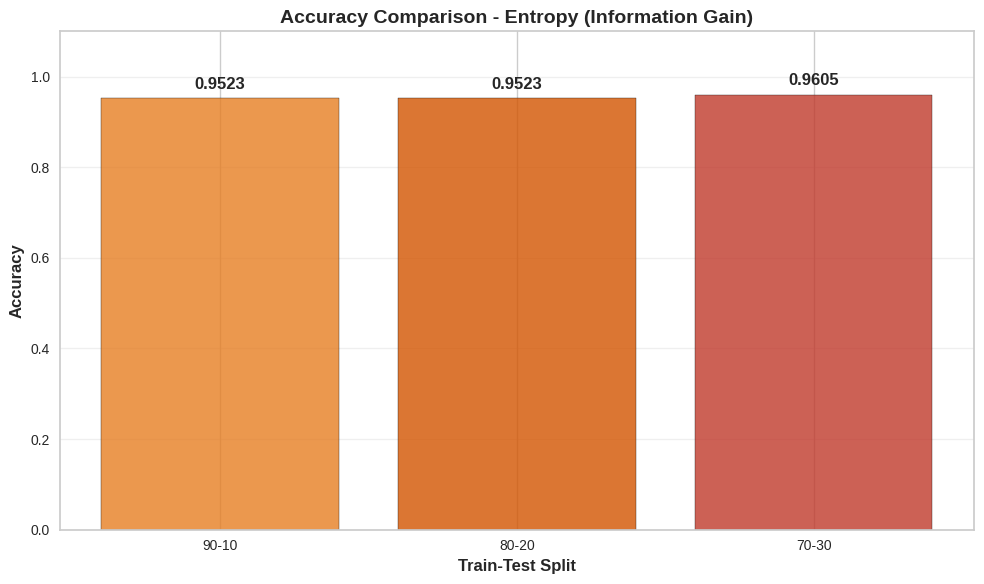

In [84]:
plt.figure(figsize=(10, 6))
splits = ['90-10', '80-20', '70-30']
accuracies_entropy = [accuracy_90_10, accuracy_80_20, accuracy_entropy_70_30]

plt.bar(splits, accuracies_entropy, color=['#e67e22', '#d35400', '#c0392b'], alpha=0.8, edgecolor='black')
plt.xlabel('Train-Test Split', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Accuracy Comparison - Entropy (Information Gain)', fontsize=14, fontweight='bold')
plt.ylim([0, 1.1])

for i, acc in enumerate(accuracies_entropy):
    plt.text(i, acc + 0.02, f'{acc:.4f}', ha='center', fontweight='bold')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_comparison_entropy.png', dpi=300, bbox_inches='tight')
plt.show()

#**Cluster**

In [ ]:
##drop class lable
if "stroke" in df.columns:
    df = df.drop("stroke", axis=1)
##scale the dataset
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df)

scaled_df = pd.DataFrame(scaled_features, columns=df.columns)

print("Scaled Data:")
print(scaled_df.head())

Scaled Data:
     gender       age  ...       bmi  smoking_status
0  1.197513 -0.072066  ... -0.216866        0.603262
1  1.197513 -0.072066  ...  0.859132        0.603262
2 -0.833495 -0.072066  ... -1.292864        0.603262
3 -0.833495 -0.072066  ...  0.859132       -1.240108
4 -0.833495 -0.072066  ... -1.292864       -1.240108

[5 rows x 10 columns]


/tmp/ipython-input-2996149490.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


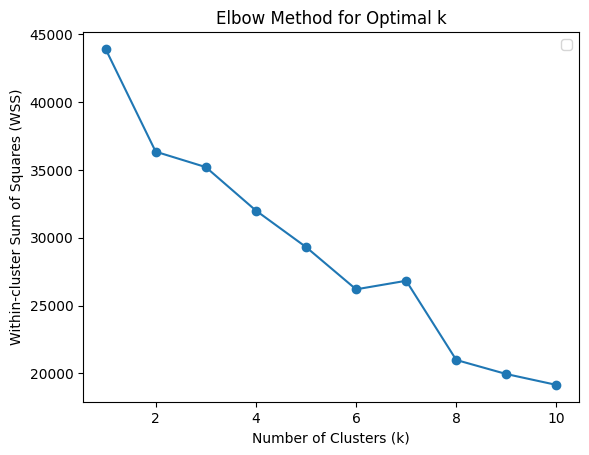

In [ ]:
wss_values = []
k_values = range (1, 11)

for k in k_values:
    kmeans = make_pipeline(StandardScaler(), KMeans(n_clusters=k))
    kmeans.fit(scaled_df)
    wss_values.append(kmeans.named_steps['kmeans'].inertia_)

# Plot the elbow method
plt.plot(k_values, wss_values, marker='o', label='WSS')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-cluster Sum of Squares (WSS)')
plt.title('Elbow Method for Optimal k')
plt.legend()
plt.show()

The Elbow curve shows major improvements at K=3, K=5, and K=8, where the WCSS drops noticeably before flattening. These points represent meaningful changes in cluster quality, which is why they were selected.


compute KMeans

In [ ]:
K_values = [10]

print("\n===== K-means Results =====")


kmeans = KMeans(n_clusters=10, random_state=42)
labels = kmeans.fit(scaled_df)
print(kmeans.cluster_centers_)


===== K-means Results =====
[[ 1.95197400e-01  1.14226403e+00 -2.83190399e-01 -2.01910759e-01
  -1.27620238e+00  1.06885702e+00 -2.00454398e-02  6.70962003e-02
  -1.11353103e+00 -1.09247849e+00]
 [-1.49868017e-01  1.04309158e+00 -2.83190399e-01 -2.01910759e-01
  -1.28513425e+00 -3.41622020e-01  1.89879854e-03  4.31167139e-02
  -2.63190710e-01  6.46550075e-01]
 [-8.05250109e-02 -5.69973827e-01 -2.83190399e-01 -2.01910759e-01
   6.10162409e-01 -3.18947636e-01 -1.01583939e+00 -5.44739929e-01
   9.37861308e-04  1.64219286e-01]
 [ 4.41789138e-01 -1.52693183e-01  4.48639005e-01  4.95268309e+00
   5.26218794e-01 -1.39271849e-01 -6.22332723e-02  1.17553580e-02
   1.08435818e-01  2.76385049e-01]
 [-8.33495001e-01 -5.57585709e-01 -2.83190399e-01 -2.01910759e-01
   6.31229831e-01 -3.02179783e-01  9.84407586e-01 -5.17886691e-01
  -1.35034366e-01  1.78212842e-01]
 [ 2.10749716e-01  1.17081378e+00 -2.83190399e-01 -2.01910759e-01
  -1.28513425e+00  1.34238130e+00 -6.28077361e-03  3.19278725e-02
   1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.18958890522736854


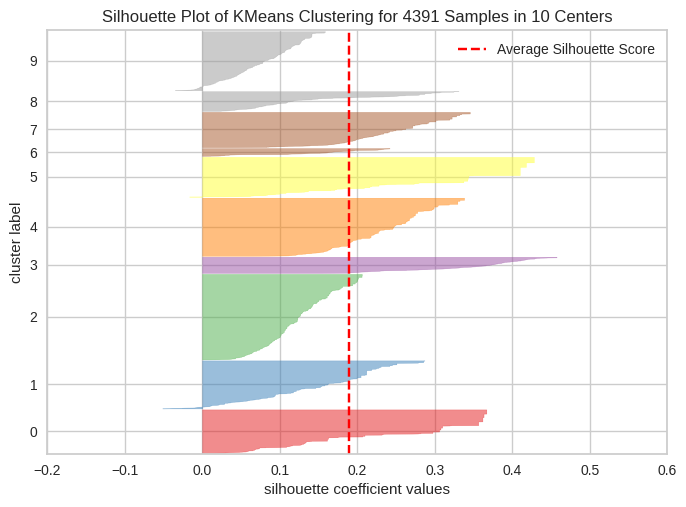

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4391 Samples in 10 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer (kmeans, color="yellowbrick")
visualizer.fit(scaled_df) # Fit the data to the visualize.
print("The average silhouette score is:", visualizer.silhouette_score_)# Print the average

visualizer.show() # Finalize and render the figure

In [ ]:
K_values = [8]

print("\n===== K-means Results =====")


kmeans = KMeans(n_clusters=8, random_state=42)
labels = kmeans.fit(scaled_df)
print(kmeans.cluster_centers_)


===== K-means Results =====
[[ 1.92975602e-01  1.13964129e+00 -2.83190399e-01 -2.01910759e-01
  -1.27622167e+00  1.06615716e+00 -1.78759948e-02  7.03038572e-02
  -1.11159439e+00 -1.09279734e+00]
 [-1.48620185e-01  1.03228579e+00 -2.83190399e-01 -2.01910759e-01
  -1.28513425e+00 -3.41813368e-01 -2.10110347e-04  5.00759053e-02
  -2.54400756e-01  6.40771981e-01]
 [-7.14528199e-02 -5.96508773e-01 -2.83190399e-01 -2.01910759e-01
   6.08153640e-01 -3.17129439e-01 -1.01583939e+00  2.30337314e-03
  -1.06183380e-02  1.75497669e-01]
 [ 4.41789138e-01 -1.52693183e-01  4.48639005e-01  4.95268309e+00
   5.26218794e-01 -1.39271849e-01 -6.22332723e-02  1.17553580e-02
   1.08435818e-01  2.76385049e-01]
 [-8.33495001e-01 -5.62690733e-01 -2.83190399e-01 -2.01910759e-01
   6.38375779e-01 -3.23200329e-01  9.84407586e-01 -2.32994480e-02
  -1.53260138e-01  2.15064357e-01]
 [ 2.05847159e-01  1.16793810e+00 -2.83190399e-01 -2.01910759e-01
  -1.28029091e+00  1.33734337e+00 -6.32506998e-03  3.44238508e-02
   1

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.20030219430022142


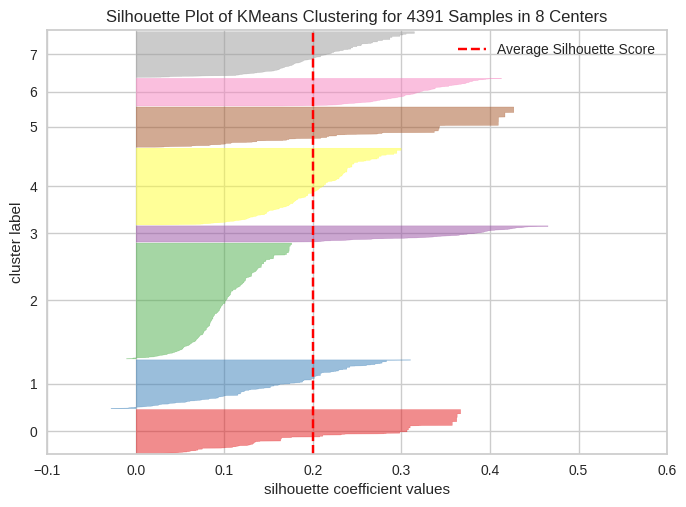

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4391 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer (kmeans, color="yellowbrick")
visualizer.fit(scaled_df) # Fit the data to the visualize.
print("The average silhouette score is:", visualizer.silhouette_score_)# Print the average

visualizer.show() # Finalize and render the figure

In [ ]:
K_values = [6]

print("\n===== K-means Results =====")


kmeans = KMeans(n_clusters=6, random_state=42)
labels = kmeans.fit(scaled_df)
print(kmeans.cluster_centers_)


===== K-means Results =====
[[ 2.62431503e-01  1.15480932e+00 -2.83190399e-01 -1.94991841e-01
  -1.27959529e+00  1.39943434e+00 -3.63387214e-03  7.91892338e-02
   4.61951666e-01 -1.15969219e+00]
 [-1.18095142e-01  1.04000211e+00 -2.83190399e-01 -2.01910759e-01
  -1.28513425e+00 -2.37655115e-01  1.71239749e-02  1.16867242e-02
  -4.32065561e-01  3.07497103e-01]
 [ 1.02487739e+00 -5.25924911e-01 -2.83190399e-01  9.83645826e-01
   6.09629002e-01 -2.86289055e-01 -7.95812221e-01  2.30982400e-02
   9.15868555e-02  1.76214367e-01]
 [-8.83163946e-02 -5.47419152e-01 -2.83190399e-01 -2.01910759e-01
   6.39611549e-01 -3.21842182e-01  9.84407586e-01 -5.92677827e-02
  -5.05524116e-02  2.21204951e-01]
 [ 6.98674859e-02 -3.11834563e-01  3.53119316e+00  3.19873281e-01
   5.31296735e-01 -2.06050135e-01 -3.41230816e-02 -5.16620897e-04
   2.40784256e-02  4.08181080e-01]
 [-8.33495001e-01 -5.70451768e-01 -2.83190399e-01 -2.01910759e-01
   5.92998583e-01 -3.01851811e-01 -1.01583939e+00 -5.97474692e-03
  -6

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.1659846227280903


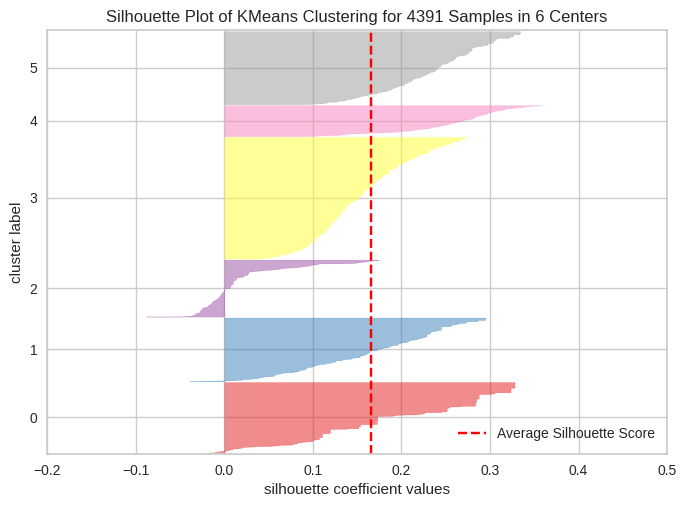

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4391 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer (kmeans, color="yellowbrick")
visualizer.fit(scaled_df) # Fit the data to the visualize.
print("The average silhouette score is:", visualizer.silhouette_score_)# Print the average

visualizer.show() # Finalize and render the figure

In [ ]:
K_values = [4]

print("\n===== K-means Results =====")


kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit(scaled_df)
print(kmeans.cluster_centers_)


===== K-means Results =====
[[ 2.56182638e-01  1.14847185e+00 -2.83190399e-01 -1.67683708e-01
  -1.27691408e+00  1.39580310e+00 -1.10586318e-03  7.64575410e-02
   4.57597689e-01 -1.15565047e+00]
 [-1.22790858e-01  1.02068122e+00 -2.21758160e-01 -1.79269790e-01
  -1.28513425e+00 -2.44494862e-01  1.21059824e-02  2.65337360e-02
  -4.32695721e-01  3.14476053e-01]
 [-3.66934795e-02 -5.45916574e-01  1.40629997e-01  1.02132500e-01
   6.18218856e-01 -2.93642574e-01 -1.01583939e+00  7.52905900e-03
   5.27084751e-03  2.01209847e-01]
 [-3.71010535e-02 -5.11675492e-01  1.06656418e-01  6.66652733e-02
   6.26519643e-01 -3.04555022e-01  9.84407586e-01 -5.78974202e-02
  -3.78923032e-02  2.41852841e-01]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.14368812572301698


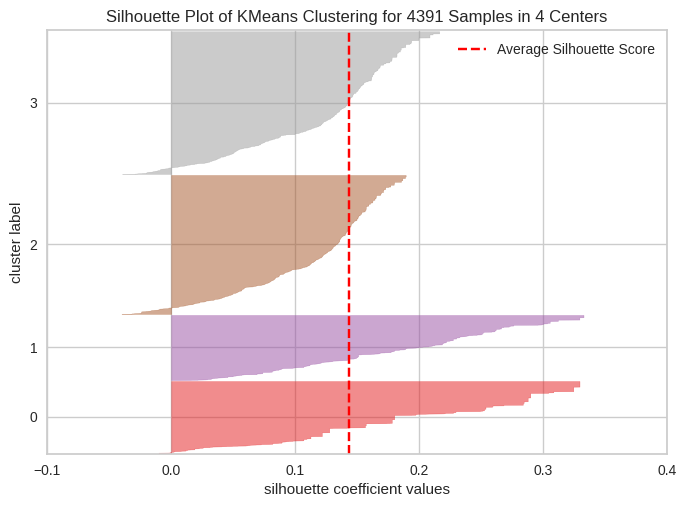

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4391 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer (kmeans, color="yellowbrick")
visualizer.fit(scaled_df) # Fit the data to the visualize.
print("The average silhouette score is:", visualizer.silhouette_score_)# Print the average

visualizer.show() # Finalize and render the figure

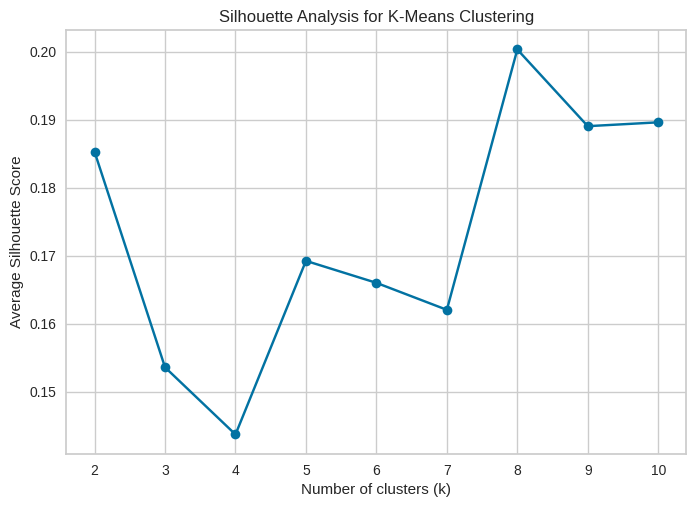

In [ ]:
k_values = range(2, 11)
silhouette_avg_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_result = kmeans.fit(scaled_df)

    silhouette_avg = silhouette_score(scaled_df, kmeans_result.labels_)
    silhouette_avg_values.append(silhouette_avg)

# Plot the silhouette scores for different values of k
plt.plot(k_values, silhouette_avg_values, marker='o')
plt.title('Silhouette Analysis for K-Means Clustering')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


The average silhouette score is: 0.18958890522736854


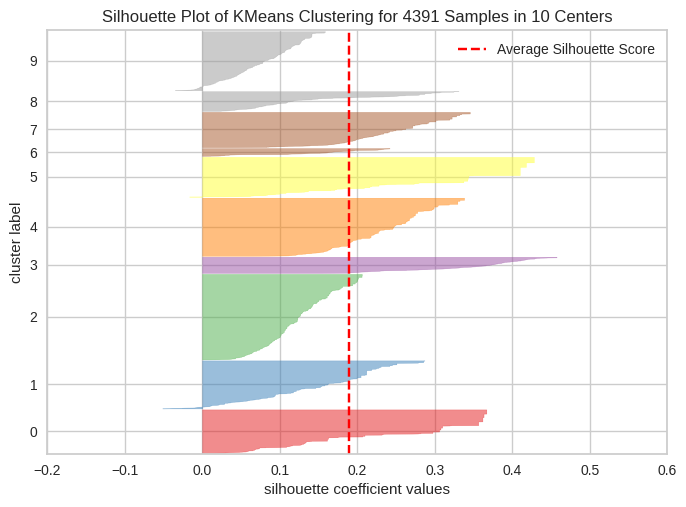

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 4391 Samples in 10 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
visualizer = SilhouetteVisualizer (kmeans, color="yellowbrick")
visualizer.fit(scaled_df) # Fit the data to the visualize.
print("The average silhouette score is:", visualizer.silhouette_score_)# Print the average

visualizer.show() # Finalize and render the figure

# Clustering

In [85]:
features = df.drop('stroke', axis=1)
print("Features used for clustering:")
print(features.columns.tolist())
print(f"\nDataset shape: {features.shape}")

Features used for clustering:
['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'Residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']

Dataset shape: (4391, 10)


##FEATURE SCALING

In [86]:
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Create DataFrame with scaled features
df_scaled = pd.DataFrame(features_scaled, columns=features.columns)

print("Features scaled using StandardScaler")
print("Scaled Data Sample:")
print(df_scaled.head())

Features scaled using StandardScaler
Scaled Data Sample:
     gender       age  hypertension  heart_disease  ever_married  work_type  \
0  1.197513 -0.072066     -0.283190       4.952683      0.778129  -0.181177   
1  1.197513 -0.072066      3.531193       4.952683      0.778129  -0.181177   
2 -0.833495 -0.072066     -0.283190      -0.201911     -1.285134  -0.181177   
3 -0.833495 -0.072066     -0.283190      -0.201911      0.778129  -0.181177   
4 -0.833495 -0.072066     -0.283190      -0.201911      0.778129  -0.181177   

   Residence_type  avg_glucose_level       bmi  smoking_status  
0       -1.015839           1.552241 -0.216866        0.603262  
1       -1.015839          -0.425099  0.859132        0.603262  
2        0.984408          -0.425099 -1.292864        0.603262  
3       -1.015839          -0.425099  0.859132       -1.240108  
4        0.984408          -0.425099 -1.292864       -1.240108  


##DETERMINE OPTIMAL K

In [93]:
# Range of K values to test
k_range = range(2, 11)

# Lists to store evaluation metrics
silhouette_scores = []
wcss_values = []

for k in k_range:
    # Fit K-means
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)

     # Get cluster labels
    cluster_labels = kmeans.labels_
 # Calculate Silhouette Score
    silhouette_avg = silhouette_score(features_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)

    # Calculate WCSS (Within-Cluster Sum of Squares)
    wcss = kmeans.inertia_
    wcss_values.append(wcss)

    print(f"K={k}: Silhouette Score={silhouette_avg:.4f}, WCSS={wcss:.2f}")



K=2: Silhouette Score=0.1852, WCSS=36338.35
K=3: Silhouette Score=0.1536, WCSS=33275.67
K=4: Silhouette Score=0.1437, WCSS=31364.30
K=5: Silhouette Score=0.1692, WCSS=27418.50
K=6: Silhouette Score=0.1660, WCSS=25834.55
K=7: Silhouette Score=0.1620, WCSS=25009.62
K=8: Silhouette Score=0.2003, WCSS=20795.96
K=9: Silhouette Score=0.1890, WCSS=20592.81
K=10: Silhouette Score=0.1896, WCSS=19443.17


## PLOT ELBOW METHOD AND SILHOUETTE SCORES

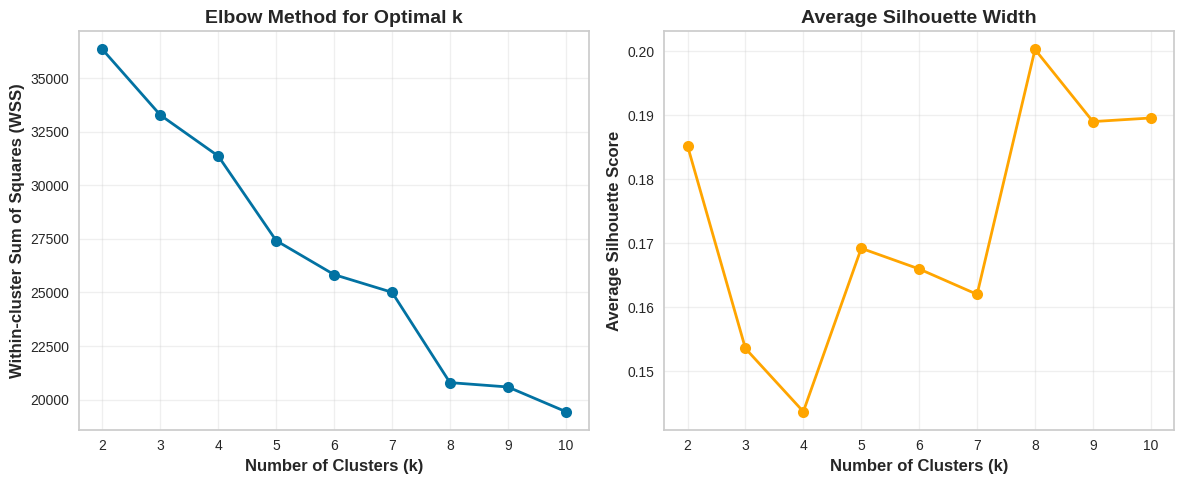

In [94]:
plt.figure(figsize=(12, 5))

# Plot 1: Elbow Method
plt.subplot(1, 2, 1)
plt.plot(list(k_range), wcss_values, marker='o', linestyle='-', linewidth=2, markersize=8)
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Within-cluster Sum of Squares (WSS)', fontsize=12, fontweight='bold')
plt.title('Elbow Method for Optimal k', fontsize=14, fontweight='bold')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

# Plot 2: Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(list(k_range), silhouette_scores, marker='o', linestyle='-',
         linewidth=2, markersize=8, color='orange')
plt.xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
plt.ylabel('Average Silhouette Score', fontsize=12, fontweight='bold')
plt.title('Average Silhouette Width', fontsize=14, fontweight='bold')
plt.xticks(list(k_range))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('optimal_k_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

## APPLY K-MEANS WITH 3 DIFFERENT K VALUES


K-MEANS CLUSTERING WITH K=2


Cluster Distribution:
  Cluster 0: 1421 samples (32.4%)
  Cluster 1: 2970 samples (67.6%)
The average silhouette score for K=2 is: 0.18524660443423885


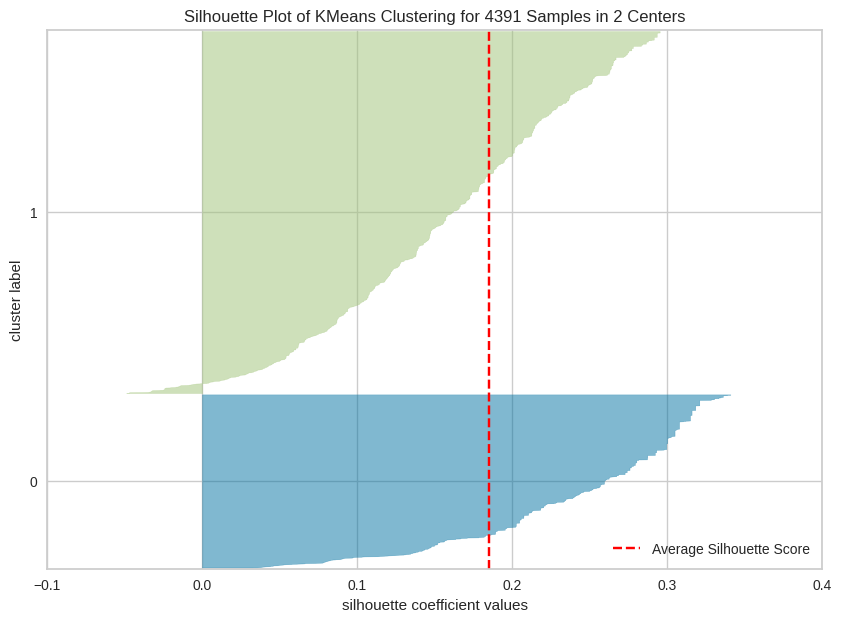

<Figure size 800x550 with 0 Axes>

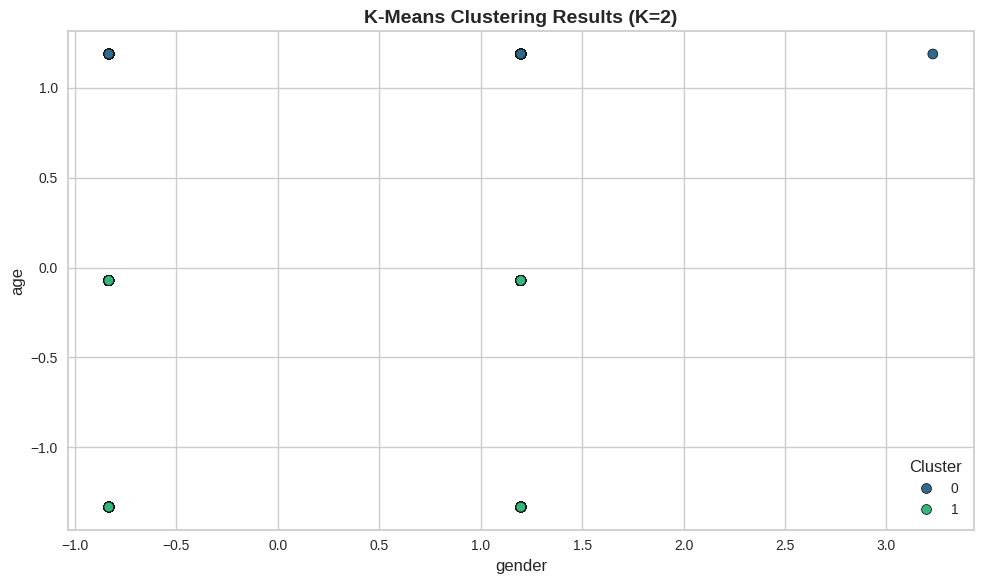


K-MEANS CLUSTERING WITH K=3


Cluster Distribution:
  Cluster 0: 1372 samples (31.2%)
  Cluster 1: 1621 samples (36.9%)
  Cluster 2: 1398 samples (31.8%)
The average silhouette score for K=3 is: 0.15356153061268019


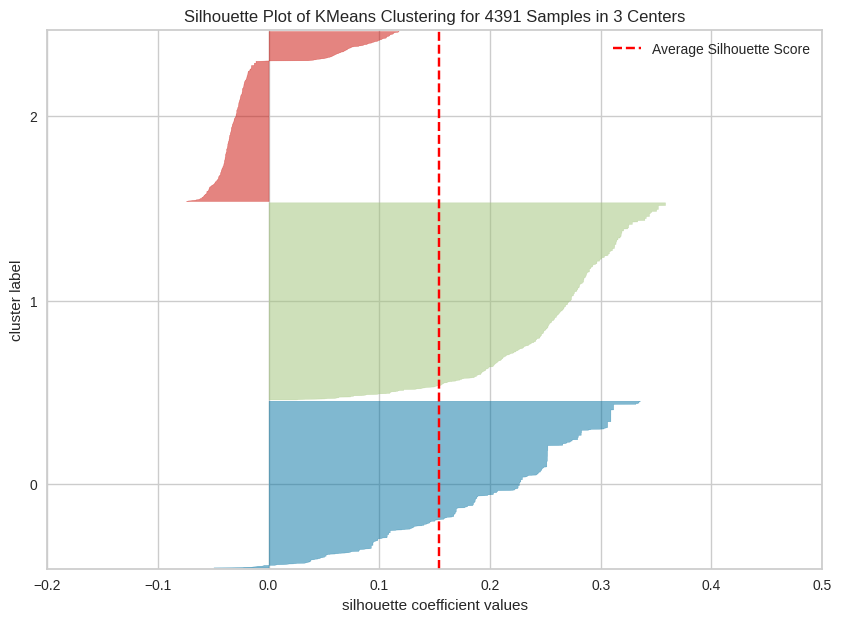

<Figure size 800x550 with 0 Axes>

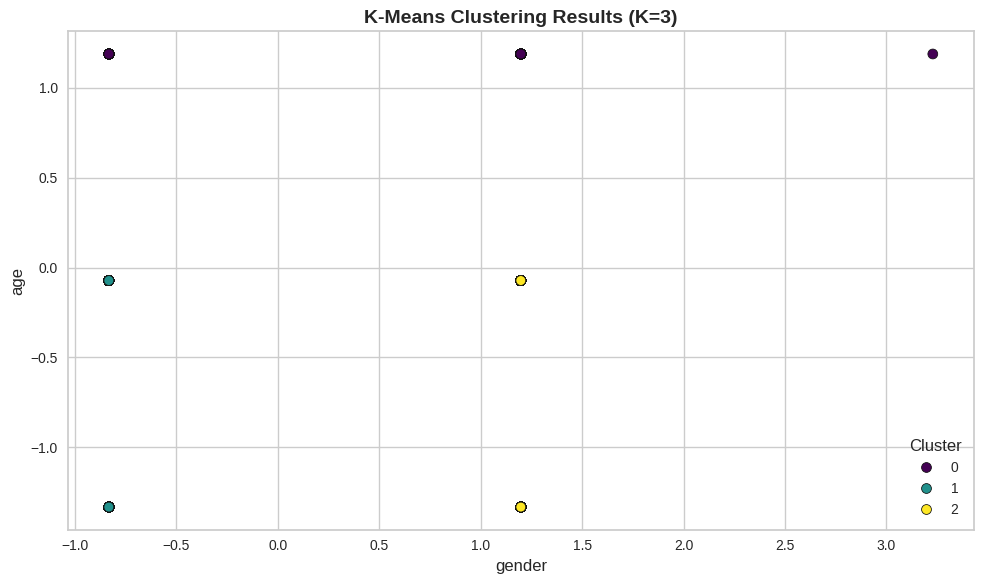


K-MEANS CLUSTERING WITH K=4


Cluster Distribution:
  Cluster 0: 753 samples (17.1%)
  Cluster 1: 683 samples (15.6%)
  Cluster 2: 1458 samples (33.2%)
  Cluster 3: 1497 samples (34.1%)
The average silhouette score for K=4 is: 0.14368812572301698


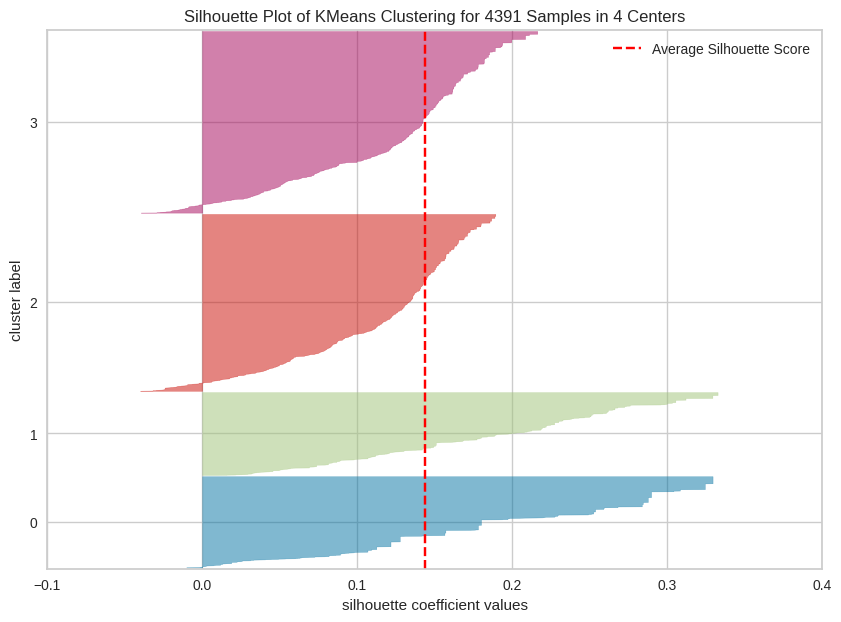

<Figure size 800x550 with 0 Axes>

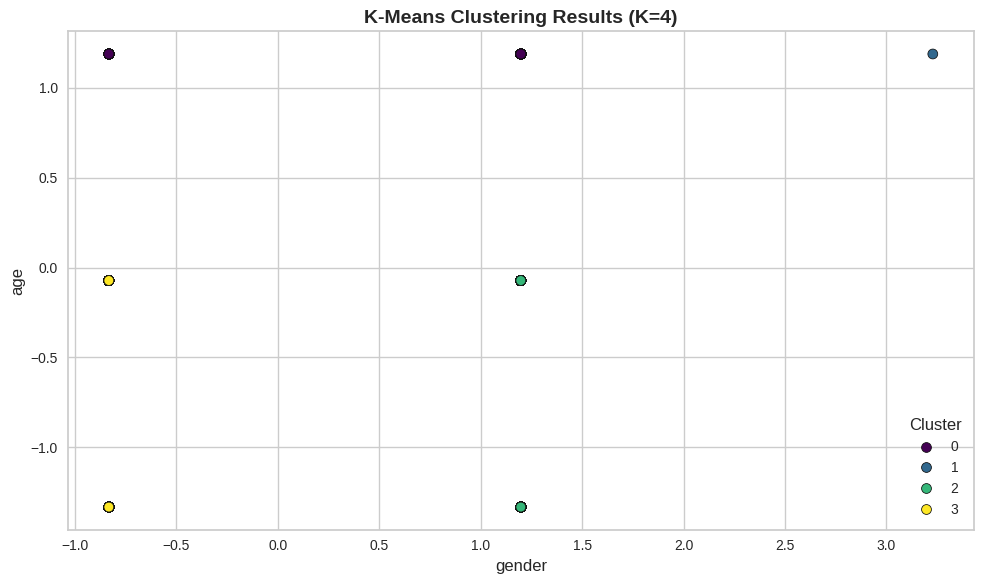

In [102]:
k_values = [2, 3, 4]
# Store results
clustering_results = []

for k in k_values:
    print(f"\n{'='*50}")
    print(f"K-MEANS CLUSTERING WITH K={k}")
    print('='*50 + "\n")

    # Set seed for random number generation
    np.random.seed(42)

    # Run K-means clustering
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans_result = kmeans.fit(features_scaled)

    # Get cluster labels
    cluster_labels = kmeans_result.labels_

    # Calculate metrics
    silhouette_avg = silhouette_score(features_scaled, cluster_labels)
    wcss = kmeans_result.inertia_

    # Store results
    clustering_results.append({
        'K': k,
        'Silhouette': silhouette_avg,
        'WCSS': wcss,
        'labels': cluster_labels,
        'model': kmeans_result
    })

    # Print cluster distribution
    print(f"\nCluster Distribution:")
    unique, counts = np.unique(cluster_labels, return_counts=True)
    for cluster_id, count in zip(unique, counts):
        percentage = (count / len(cluster_labels)) * 100
        print(f"  Cluster {cluster_id}: {count} samples ({percentage:.1f}%)")

    # SILHOUETTE VISUALIZATION
    fig_sil, ax_sil = plt.subplots(figsize=(10, 7))
    visualizer = SilhouetteVisualizer(kmeans_result, colors='yellowbrick', ax=ax_sil)
    visualizer.fit(features_scaled)
    print(f"The average silhouette score for K={k} is: {visualizer.silhouette_score_}")
    visualizer.show()
    plt.savefig(f'silhouette_plot_k{k}.png', dpi=300, bbox_inches='tight')
    plt.close(fig_sil) # Close the figure to prevent it from displaying multiple times if run in a notebook

    # CLUSTER VISUALIZATION
    df_temp_scaled = df_scaled.copy()
    df_temp_scaled['Cluster'] = cluster_labels
    # Use first two columns as features for plotting
    feature1 = df_temp_scaled.columns[0]
    feature2 = df_temp_scaled.columns[1]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=df_temp_scaled[feature1],
                    y=df_temp_scaled[feature2],
                    hue='Cluster',
                    data=df_temp_scaled,
                    palette='viridis',
                    s=50,
                    edgecolor='k')
    plt.title(f'K-Means Clustering Results (K={k})', fontsize=14, fontweight='bold')
    plt.xlabel(feature1, fontsize=12)
    plt.ylabel(feature2, fontsize=12)
    plt.legend(title='Cluster')
    plt.tight_layout()
    plt.savefig(f'clusters_visualization_k{k}.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close() # Close the current figure


## RESULTS SUMMARY TABLE

In [104]:
summary_table = pd.DataFrame({
    'K': [r['K'] for r in clustering_results],
    'Average Silhouette width': [f"{r['Silhouette']:.4f}" for r in clustering_results],
    'total within-cluster sum of square': [f"{r['WCSS']:.2f}" for r in clustering_results]
})

print(summary_table.to_string(index=False))
print()


 K Average Silhouette width total within-cluster sum of square
 2                   0.1852                           36338.35
 3                   0.1536                           33275.67
 4                   0.1437                           31364.30



In [105]:
# Find K with highest Silhouette Score
best_silhouette_idx = np.argmax([r['Silhouette'] for r in clustering_results])
best_k_silhouette = clustering_results[best_silhouette_idx]['K']

print(f"Best K based on Silhouette Score: K={best_k_silhouette}")
print(f"  Silhouette Score: {clustering_results[best_silhouette_idx]['Silhouette']:.4f}")

# Based on Elbow method (look at the plot - manual decision)
print("\nBased on Elbow Method: Check the 'Elbow Method' plot above")
print("The optimal K is where the curve starts to flatten (elbow point)")

print("\n" + "="*60)
print("RECOMMENDATION")
print("="*60)
print("Based on the majority rule (combining both methods),")
print(f"the recommended number of clusters is: K={best_k_silhouette}")
print("="*60 + "\n")

Best K based on Silhouette Score: K=2
  Silhouette Score: 0.1852

Based on Elbow Method: Check the 'Elbow Method' plot above
The optimal K is where the curve starts to flatten (elbow point)

RECOMMENDATION
Based on the majority rule (combining both methods),
the recommended number of clusters is: K=2



## DETAILED ANALYSIS OF BEST K

In [106]:
best_result = clustering_results[best_silhouette_idx]
best_labels = best_result['labels']

# Add cluster labels to original dataframe
df['Cluster'] = best_labels

# Analyze each cluster
print("Cluster Characteristics:\n")
for cluster_id in range(best_k_silhouette):
    cluster_data = df[df['Cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} Statistics:")
    print(f"Size: {len(cluster_data)} samples ({len(cluster_data)/len(df)*100:.1f}%)")
    print("\nMean values:")
    print(cluster_data.drop(['Cluster', 'stroke'], axis=1).mean())
    print("-" * 50)

Cluster Characteristics:


Cluster 0 Statistics:
Size: 1421 samples (32.4%)

Mean values:
gender               0.458128
age                  1.922590
hypertension         0.004926
heart_disease        0.004222
ever_married         0.008445
work_type            2.936664
Residence_type       0.509500
avg_glucose_level    1.242083
bmi                  1.235749
smoking_status       0.801548
dtype: float64
--------------------------------------------------

Cluster 1 Statistics:
Size: 2970 samples (67.6%)

Mean values:
gender               0.387542
age                  0.643098
hypertension         0.107407
heart_disease        0.055892
ever_married         0.916835
work_type            1.849158
Residence_type       0.507071
avg_glucose_level    1.202020
bmi                  1.185185
smoking_status       1.605724
dtype: float64
--------------------------------------------------
